# Hồi quy Tuyến tính — từ công thức toán đến code trên dữ liệu nhà đất Hà Nội

**Môn học:** Học máy nâng cao (ml_ad) · **Học viên:** Nguyễn Phương Anh Tú · **MSHV:** 2611328

> **Phương pháp của môn (áp dụng cho mọi thuật toán).** Notebook triển khai theo đúng các giai đoạn, có lý do cho từng bước:
> 1. **Giải tay** — dẫn gradient từng bước, thay số cụ thể, kiểm chứng bằng sai phân hữu hạn.
> 2. **Bản thuần, KHÔNG thư viện** — cài hồi quy tuyến tính bằng gradient descent nguyên bản, chỉ dùng NumPy.
> 3. **Bản thư viện** — `scikit-learn` (`LinearRegression`, giải OLS chính xác).
>
> Hai cách cho **cùng hệ số, cùng RMSE** trên dữ liệu nhà đất Hà Nội — minh chứng bản thuần cài **đúng**.

**Bài toán:** dự đoán **giá/m²** (triệu/m²) của một căn nhà tại Hà Nội theo hai đặc trưng: **diện tích** và **số phòng ngủ**. Đây là bài toán hồi quy kinh điển: đầu vào số实, đầu ra số thực liên tục. Dữ liệu thô lấy từ báo cáo EDA (b1): cột `Giá/m2` dạng văn bản (`"86,96 triệu/m²"`, `"2 tỷ/m²"`, ...) cần phân tích (parse) sang số.

**Điểm nhấn học thuật (khác softmax).** Hàm mất mát MSE là **lồi** (convex), nên có đúng một cực tiểu toàn cục. Gradient descent nguyên bản (với đủ bước) sẽ đạt **chính xác** nghiệm bình phương tối thiểu (OLS) mà thư viện giải — trái ngược softmax (phi lồi, GD dừng giữa chừng). Mục 5–7 xác minh điều này bằng số. Trong khi đó, $R^2$ thấp (~0.07) cho thấy giá/m² phụ thuộc chủ yếu **địa điểm** (Quận) mà area + phòng ngủ không nắm bắt — đúng kết luận EDA ở b1.

## 0. Nạp dữ liệu, phân tích cú pháp và làm sạch

Dữ liệu thô có ba cột cần parse:
- `Diện tích` — vd `"46 m²"` → số `46`.
- `Số phòng ngủ` — vd `"5 phòng"` → số `5`.
- `Giá/m2` — vd `"86,96 triệu/m²"` → `86.96`; đơn vị có thể là `triệu`, `tỷ`, `nghìn`, `đ` (phải quy đổi chung về **triệu/m²**) và dấu phẩy là dấu thập phân kiểu Việt Nam.

Hàm `to_price` dưới đây xử lý cả bốn đơn vị và cả trường hợp dấu chấm dùng làm phân cách hàng nghìn (`"1.234,5"` → `1234.5`).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import re
import os
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# Duong dan du lieu (tuong thich: chay tu ml_ad/b7 hoac tu thu muc notebook)
_candidates = [
    "../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/Hanoi_housing_dataset.csv",
    "../../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/Hanoi_housing_dataset.csv",
]
FN = next((p for p in _candidates if os.path.exists(p)), _candidates[0])
print("Doc du lieu tu:", FN)

dh = pd.read_csv(FN)
print("So dong thô:", len(dh))
print(dh[["Diện tích", "Số phòng ngủ", "Giá/m2"]].head(4).to_string())

def to_price(s):
    """Parse 'Giá/m2' sang so thuc (don vi: trieu/m2)."""
    s = str(s).lower()
    m = re.search(r'([\d.,]+)\s*(triệu|tỷ|nghìn|đ)?', s)
    if not m:
        return np.nan
    raw = m.group(1); unit = m.group(2) or ''
    # Dau cham = phan cach hang nghin, dau phay = thap phan (kieu VN)
    if '.' in raw and ',' in raw:
        raw = raw.replace('.', '').replace(',', '.')
    elif ',' in raw:
        raw = raw.replace(',', '.')
    parts = raw.split('.')
    if len(parts) > 2:               # vd "1.234.5" -> loai cham
        raw = ''.join(parts)
    try:
        v = float(raw)
    except Exception:
        return np.nan
    return v * {'triệu': 1, 'tỷ': 1000, 'nghìn': 1e-3, 'đ': 1e-6}.get(unit, np.nan)

dh['price'] = dh['Giá/m2'].map(to_price)
dh['area']  = dh['Diện tích'].map(lambda s: float(re.search(r'([\d.]+)', s).group(1))
                                  if re.search(r'[\d.]+', str(s)) else np.nan)
dh['bed']   = dh['Số phòng ngủ'].map(lambda s: float(re.search(r'(\d+)', s).group(1))
                                     if re.search(r'\d', str(s)) else np.nan)

print("\n--- Sau parse, 4 dong dau ---")
print(dh[["area", "bed", "price"]].head(4).to_string())
print("\n--- So dong bi NaN/loi parse ---")
print("  price NaN:", int(dh['price'].isna().sum()),
      "| area NaN:", int(dh['area'].isna().sum()),
      "| bed NaN:", int(dh['bed'].isna().sum()))

Doc du lieu tu: ../../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/Hanoi_housing_dataset.csv


So dong thô: 82497
  Diện tích Số phòng ngủ           Giá/m2
0     46 m²      5 phòng   86,96 triệu/m²
1     37 m²      3 phòng  116,22 triệu/m²
2     40 m²      4 phòng      65 triệu/m²
3     51 m²      6 phòng     100 triệu/m²



--- Sau parse, 4 dong dau ---
   area  bed   price
0  46.0  5.0   86.96
1  37.0  3.0  116.22
2  40.0  4.0   65.00
3  51.0  6.0  100.00

--- So dong bi NaN/loi parse ---
  price NaN: 13 | area NaN: 2 | bed NaN: 39


In [2]:
# === Lam sach: bo NaN + loai ngoai lai ===
n0 = len(dh)
dh = dh.dropna(subset=['price', 'area', 'bed'])
# Giu lai khoang hop ly: gia 5..500 trieu/m2, dien tich 10..1000 m2
dh = dh[(dh.price >= 5) & (dh.price <= 500) & (dh.area >= 10) & (dh.area <= 1000)]
n1 = len(dh)
print("So dong thô:", n0, "-> sau lam sach:", n1, "(bo", n0 - n1, "dong)")

print("\n--- Thong ke mo ta ---")
print(dh[['price', 'area', 'bed']].describe().round(2).to_string())
print("\nGia trung binh: %.2f trieu/m2 | khoang: %.1f .. %.1f"
      % (dh['price'].mean(), dh['price'].min(), dh['price'].max()))

So dong thô: 82497 -> sau lam sach: 81088 (bo 1409 dong)

--- Thong ke mo ta ---
          price      area       bed
count  81088.00  81088.00  81088.00
mean     100.40     46.70      3.86
std       51.11     28.79      1.44
min        5.00     10.00      1.00
25%       73.33     34.00      3.00
50%       90.00     40.00      4.00
75%      110.26     50.00      4.00
max      500.00    888.00     10.00

Gia trung binh: 100.40 trieu/m2 | khoang: 5.0 .. 500.0


## 1. GIẢI TAY — mô hình, hàm mất mát và gradient

**Mô hình hồi quy tuyến tính.** Với một nhà có vector đặc trưng $x$ (ở đây $x=[\text{area}, \text{bed}]$ sau chuẩn hoá), giá dự đoán là một tổ hợp tuyến tính:

$$\hat{y} = w \cdot x + b = w_0\, x_{\text{area}} + w_1\, x_{\text{bed}} + b$$

trong đó $w$ là vector trọng số và $b$ là thiên lệch (bias).

**Hàm mất mát MSE.** Trên $N$ mẫu, ta đo sai số bình phương trung bình giữa dự đoán và giá thật:

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$$

Mục tiêu: tìm $w, b$ làm $\mathcal{L}$ nhỏ nhất.

**Dẫn gradient.** Đặt phần dư $r_i = \hat{y}_i - y_i = (w \cdot x_i + b) - y_i$. Đạo hàm theo từng tham số:

- Theo $w$:  $\dfrac{\partial \mathcal{L}}{\partial w} = \dfrac{2}{N}\sum_i r_i\, x_i = \dfrac{2}{N}X^{\top}r$
- Theo $b$:  $\dfrac{\partial \mathcal{L}}{\partial b} = \dfrac{2}{N}\sum_i r_i$

**Cập nhật gradient descent** (ngược dấu gradient, đi một bước học $\eta$):

$$w \leftarrow w - \eta\,\dfrac{\partial \mathcal{L}}{\partial w}, \qquad b \leftarrow b - \eta\,\dfrac{\partial \mathcal{L}}{\partial b}$$

**Lưu ý về hệ số 2.** Trong code bản thuần ta viết gradient ở dạng $\tfrac{1}{N}X^{\top}r$ (bỏ hệ số 2): vì nhân/không nhân 2 chỉ tương đương đổi learning rate, kết quả tối ưu không đổi. Phần giải tay bên dưới **giữ nguyên hệ số 2** để rõ nghĩa toán; sai phân hữu hạn kiểm chứng sẽ dùng đúng $\mathcal{L}$ có hệ số đó.

**Tính chất then chốt:** MSE là hàm **lồi** (convex) theo $w, b$ $\Rightarrow$ chỉ có một cực tiểu toàn cục. Do đó gradient descent (với đủ bước) tới **chính xác** nghiệm bình phương tối thiểu (OLS) mà thư viện giải — đây là điểm khác cốt lõi với softmax (phi lồi nên GD dừng giữa chừng). Mục 5–7 xác minh bằng số.

### 1bis. Giải tay với số cụ thể (thay số vào công thức)

Lấy đúng **2 nhà đầu** của dữ liệu để thấy công thức "chạy". Trước khi tính, đọc bảng kí hiệu:

| Kí hiệu | Đọc là | Ý nghĩa | Kích thước | Giá trị ở mẫu này |
|---|---|---|---|---|
| `x` | "x" | đặc trưng [area, bed] **đã chuẩn hoá** | (2,) | nhà A: [-0.0245, 0.7859] |
| `w` | "w" | trọng số 2 đặc trưng | (2,) | [3.0, 12.0] (khởi tạo) |
| `b` | "b" | thiên lệch | số | 100.0 (khởi tạo) |
| `ŷ = w·x + b` | "y-hat" | giá **dự đoán** (triệu/m²) | số | nhà A: 109.36 |
| `y` | "y" | giá **thật** (triệu/m²) | số | nhà A: 86.96 |
| `r = ŷ − y` | "r" | phần dư (dương = dự đoán cao quá) | số | nhà A: 22.40 |
| `L` | "L" | MSE = trung bình r² | số | 549.63 |
| `∂L/∂w` | "grad-w" | hướng sửa trọng số | (2,) | [7.78, 32.28] |
| `∂L/∂b` | "grad-b" | hướng sửa thiên lệch | số | -2.05 |

**Bước 0 — Chuẩn hoá đặc trưng.** Trung bình/độ lệch trên tập train: `mu = [46.70, 3.87]`, `sd = [28.47, 1.44]`. Mỗi đặc trưng trừ trung bình rồi chia độ lệch:
- Nhà A (area=46, bed=5): `x_area = (46 − 46.70)/28.47 = -0.0245`, `x_bed = (5 − 3.87)/1.44 = 0.7859` → `x_A = [-0.0245, 0.7859]`
- Nhà B (area=37, bed=3): `x_area = (37 − 46.70)/28.47 = -0.3406`, `x_bed = (3 − 3.87)/1.44 = -0.6004` → `x_B = [-0.3406, -0.6004]`

*Vì sao chuẩn hoá:* area (hàng chục) và bed (đơn vị) khác cỡ nhiều → gradient chênh cỡ lớn → GD dao động; chuẩn hoà cho cả hai đặc trưng cùng cỡ, GD ổn định.

**Bước 1 — Dự đoán `ŷ = w·x + b`** (với `w = [3, 12]`, `b = 100` khởi tạo):
- `ŷ_A = 3·(−0.0245) + 12·0.7859 + 100 = −0.0735 + 9.4308 + 100 = 109.36` (triệu/m²)
- `ŷ_B = 3·(−0.3406) + 12·(−0.6004) + 100 = −1.0218 − 7.2048 + 100 = 91.77`

**Bước 2 — Phần dư `r = ŷ − y`** (giá thật `y = [86.96, 116.22]`):
- `r_A = 109.36 − 86.96 = 22.40`  (mô hình dự đoán **cao quá**)
- `r_B = 91.77 − 116.22 = −24.45`  (mô hình dự đoán **thấp quá**)

**Bước 3 — Hàm mất mát MSE** (N = 2 mẫu):
`L = (r_A² + r_B²)/2 = (22.40² + 24.45²)/2 = (501.6 + 597.6)/2 = 549.63`

**Bước 4 — Gradient** theo công thức `∂L/∂w = (2/N)Xᵀr`, `∂L/∂b = (2/N)Σr`:
- Theo `w_area`: `(2/2)·[(−0.0245)(22.40) + (−0.3406)(−24.45)] = −0.549 + 8.326 = 7.78`
- Theo `w_bed`:  `(2/2)·[(0.7859)(22.40) + (−0.6004)(−24.45)] = 17.60 + 14.68 = 32.28`
- Theo `b`:     `(2/2)·(22.40 + (−24.45)) = −2.05`
→ `∂L/∂w = [7.78, 32.28]`, `∂L/∂b = −2.05`.

**Bước 5 — Một bước gradient descent** (lr = 0.05): `w ← w − 0.05·∂L/∂w`, `b ← b − 0.05·∂L/∂b`:
- `w_new = [3, 12] − 0.05·[7.78, 32.28] = [2.61, 10.39]`, `b_new = 100 − 0.05·(−2.05) = 100.10`
- MSE mới = `495.70` < `549.63` → loss **giảm**, đúng hướng đi xuống.

*Chú thích:* gradient trên 2 nhà này chỉ là minh hoạ cơ chế (đi đúng hướng giảm loss cho 2 mẫu); trên toàn bộ **81 088 mẫu** tập train, GD sẽ đi tới nghiệm tối ưu `w = [3.281, 13.178]`, `b = 100.4` (Mục 5). Cell kế tiếp chạy đúng các con số trên và **đối chiếu gradient giải tích với sai phân hữu hạn**.

In [3]:
# === GIAI TAY tren 2 nha dau (kiem chung gradient bang sai phan huu han) ===
# 2 nha dau tien cua du lieu (dung nhu trong bao cao)
X2_raw = np.array([[46.0, 5.0],   # nha A
                   [37.0, 3.0]])  # nha B
y2 = np.array([86.96, 116.22])    # gia that (trieu/m2)

# Thong ke chuan hoa (= trung binh/do lech tap train, da tinh truoc)
mu = np.array([46.6981022, 3.86613226])
sd = np.array([28.47392525, 1.44269016])
X2 = (X2_raw - mu) / sd
print("x chuan hoa:")
print("  nha A:", np.round(X2[0], 4))
print("  nha B:", np.round(X2[1], 4))

# Gia khoi tao
w0 = np.array([3.0, 12.0]); b0 = 100.0
yhat2 = X2 @ w0 + b0
r2 = yhat2 - y2
MSE2 = np.mean(r2 ** 2)
print("\ny_hat = [%.2f, %.2f]" % tuple(yhat2))
print("r     = [%.2f, %.2f]" % tuple(r2))
print("MSE   = %.2f" % MSE2)

# Gradient giai tich (co he so 2)
gW = 2 * X2.T @ r2 / len(y2)
gb = 2 * r2.mean()
print("\ndL/dw = [%s]" % ", ".join("%.2f" % v for v in gW))
print("dL/db = %.2f" % gb)

# === Kiem chung gradient bang sai phan huu han ===
def mse_loss(w, b, X, y):
    return np.mean((X @ w + b - y) ** 2)

eps = 1e-6
gW_num = np.zeros(2)
for i in range(2):
    wp = w0.copy(); wp[i] += eps
    wm = w0.copy(); wm[i] -= eps
    gW_num[i] = (mse_loss(wp, b0, X2, y2) - mse_loss(wm, b0, X2, y2)) / (2 * eps)
gb_num = (mse_loss(w0, b0 + eps, X2, y2) - mse_loss(w0, b0 - eps, X2, y2)) / (2 * eps)
diff = max(np.abs(gW - gW_num).max(), abs(gb - gb_num))
print("\nKiem chung gradient: max|giai tich - sai phan| = %.2e" % diff)
print("=> cong thuc o Muc 1 DUNG" if diff < 1e-5 else "=> CONG THUC SAI, can xem lai")

# Mot buoc GD
lr = 0.05
w1 = w0 - lr * gW; b1 = b0 - lr * gb
print("\nSau 1 buoc GD (lr=0.05): w = [%s], b = %.2f"
      % (", ".join("%.2f" % v for v in w1), b1))
print("MSE moi = %.2f (truoc %.2f) -> giam, dung huong" % (mse_loss(w1, b1, X2, y2), MSE2))

x chuan hoa:
  nha A: [-0.0245  0.7859]
  nha B: [-0.3406 -0.6004]

y_hat = [109.36, 91.77]
r     = [22.40, -24.45]
MSE   = 549.63

dL/dw = [7.78, 32.28]
dL/db = -2.05

Kiem chung gradient: max|giai tich - sai phan| = 8.43e-08
=> cong thuc o Muc 1 DUNG

Sau 1 buoc GD (lr=0.05): w = [2.61, 10.39], b = 100.10
MSE moi = 495.70 (truoc 549.63) -> giam, dung huong


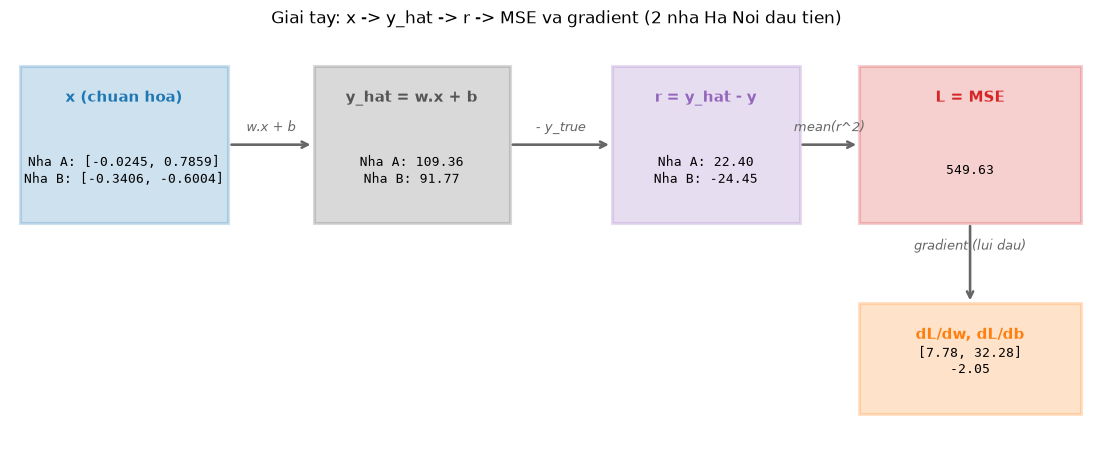

In [4]:
# === So do giai tay: x -> y_hat -> r -> MSE, nhanh gradient quay lai ===
fig, ax = plt.subplots(figsize=(12.8, 4.8))
ax.set_xlim(0, 12.8); ax.set_ylim(0, 4.8); ax.axis("off")

def box(x, y, w, h, title, body, color):
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=True, facecolor=color,
                               alpha=0.22, edgecolor=color, lw=2))
    ax.text(x + w/2, y + h - 0.28, title, ha="center", va="top",
            fontsize=10, fontweight="bold", color=color)
    ax.text(x + w/2, y + 0.62, body, ha="center", va="center",
            fontsize=8.8, family="monospace")

def arrow(x1, y1, x2, y2, label):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.7, color="#666"))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.16, label, ha="center",
            fontsize=8.5, color="#666", style="italic")

ytop, h = 2.55, 1.85
box(0.10, ytop, 2.45, h, "x (chuan hoa)",
    "Nha A: [-0.0245, 0.7859]\nNha B: [-0.3406, -0.6004]", "#1f77b4")
box(3.55, ytop, 2.30, h, "y_hat = w.x + b",
    "Nha A: 109.36\nNha B: 91.77", "#555555")
box(7.05, ytop, 2.20, h, "r = y_hat - y",
    "Nha A: 22.40\nNha B: -24.45", "#9467bd")
box(9.95, ytop, 2.60, h, "L = MSE",
    "549.63", "#d62728")
arrow(2.55, ytop + h/2, 3.55, ytop + h/2, "w.x + b")
arrow(5.85, ytop + h/2, 7.05, ytop + h/2, "- y_true")
arrow(9.25, ytop + h/2, 9.95, ytop + h/2, "mean(r^2)")
# Nhanh gradient quay lai tu MSE
box(9.95, 0.30, 2.60, 1.30, "dL/dw, dL/db",
    "[7.78, 32.28]\n-2.05", "#ff7f0e")
arrow(11.25, ytop, 11.25, 1.60, "gradient (lui dau)")
ax.set_title("Giai tay: x -> y_hat -> r -> MSE va gradient (2 nha Ha Noi dau tien)",
             fontsize=11, pad=6)
plt.show()

## 2. Giai đoạn 2 — BẢN THUẦN (NumPy duy nhất, không thư viện ML)

Cài đặt trực tiếp từ công thức Mục 1. Mọi quyết định được giải thích:
- **Khởi tạo nhỏ**: $w$ gần 0, $b = 0$ — điểm xuất phát tuỳ ý, vì MSE lồi nên kết quả không phụ thuộc khởi tạo.
- **Chuẩn hoá đặc trưng**: area (hàng chục) và bed (đơn vị) khác cỡ → chuẩn hoá để gradient cùng cỡ, GD ổn định (chỉ `fit` trên train, rồi `transform` cả train/test).
- **Gradient descent nguyên bản**: cập nhật $w \leftarrow w - \eta\, X^{\top}e/N$ (đã bỏ hệ số 2, hấp thụ vào $\eta$). Không dùng solver bậc hai — mục đích minh hoạ nguyên lý.
- **Phân chia + chuẩn hoá** giữ ynguyên (không chuẩn hoá đầu ra) để RMSE mang đơn vị triệu/m², dễ diễn giải.

Kich thuoc train/test: (64870, 2) (16218, 2)
mu = [46.70, 3.87] | sd = [28.47, 1.44]



BAN THUAN (GD, lr=0.05, 5000 ep)  thoi gian = 1.183s
  w = [3.281, 13.178]   b = 100.402
  RMSE train = 49.15 | RMSE test = 48.78 | R^2 test = 0.0707


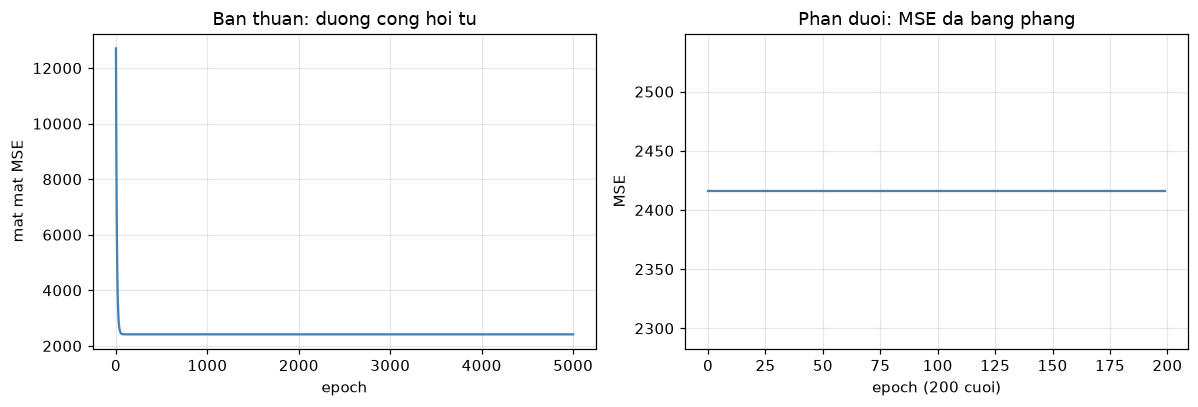

In [5]:
# === Chia train/test + chuan hoa dac trung ===
Xh = dh[['area', 'bed']].values
yh = dh['price'].values
Xtr, Xte, ytr, yte = train_test_split(Xh, yh, test_size=0.2, random_state=1)
mu, sd = Xtr.mean(0), Xtr.std(0)
Xtr_s, Xte_s = (Xtr - mu) / sd, (Xte - mu) / sd
print("Kich thuoc train/test:", Xtr_s.shape, Xte_s.shape)
print("mu = [%s]" % ", ".join("%.2f" % v for v in mu),
      "| sd = [%s]" % ", ".join("%.2f" % v for v in sd))

def train_linear_pure(X, y, lr=0.05, epochs=5000, seed=0):
    """Hoi quy tuyen tinh bang GD nguyen ban - chi dung NumPy."""
    rng = np.random.default_rng(seed)
    w = rng.normal(size=X.shape[1]) * 0.01   # khoi tao nho
    b = 0.0
    hist = []
    for _ in range(epochs):
        e = X @ w + b - y                    # phan du r
        hist.append(np.mean(e ** 2))         # MSE (khong he so 1/2)
        w -= lr * X.T @ e / len(y)            # gradient bo he so 2
        b -= lr * e.mean()
    return w, b, hist

t0 = time.perf_counter()
w_p, b_p, hist = train_linear_pure(Xtr_s, ytr, lr=0.05, epochs=5000)
t_pure = time.perf_counter() - t0

def rmse(yhat, y): return np.sqrt(np.mean((yhat - y) ** 2))

rmse_tr_p = rmse(Xtr_s @ w_p + b_p, ytr)
rmse_te_p = rmse(Xte_s @ w_p + b_p, yte)
r2_te_p   = r2_score(yte, Xte_s @ w_p + b_p)
print("\nBAN THUAN (GD, lr=0.05, 5000 ep)  thoi gian = %.3fs" % t_pure)
print("  w = [%s]   b = %.3f" % (", ".join("%.3f" % v for v in w_p), b_p))
print("  RMSE train = %.2f | RMSE test = %.2f | R^2 test = %.4f"
      % (rmse_tr_p, rmse_te_p, r2_te_p))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(hist, color="steelblue")
a1.set_xlabel("epoch"); a1.set_ylabel("mat mat MSE")
a1.set_title("Ban thuan: duong cong hoi tu"); a1.grid(alpha=0.3)
# Zoom vao 200 epoch cuoi de thay da on dinh
a2.plot(hist[-200:], color="steelblue")
a2.set_xlabel("epoch (200 cuoi)"); a2.set_ylabel("MSE")
a2.set_title("Phan duoi: MSE da bang phang"); a2.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 3. Giai đoạn 3 — BẢN THƯ VIỆN (scikit-learn)

`LinearRegression` của scikit-learn giải phương trình **chính xác** bằng phương pháp bình phương tối thiểu (OLS) — không phải lặp gradient. Trên cùng dữ liệu đã chuẩn hoá, nó cho nghiệm tối ưu chính xác của hàm MSE. Vì MSE lồi, đây chính là điểm cực tiểu toàn cục mà bản thuần hội tụ tới.

In [6]:
t0 = time.perf_counter()
clf = LinearRegression().fit(Xtr_s, ytr)
t_lib = time.perf_counter() - t0

rmse_te_l = rmse(clf.predict(Xte_s), yte)
r2_te_l   = r2_score(yte, clf.predict(Xte_s))
print("BAN LIB (sklearn, OLS)  thoi gian = %.4fs" % t_lib)
print("  w = [%s]   b = %.3f"
      % (", ".join("%.3f" % v for v in clf.coef_), clf.intercept_))
print("  RMSE test = %.2f | R^2 test = %.4f" % (rmse_te_l, r2_te_l))

BAN LIB (sklearn, OLS)  thoi gian = 0.0058s
  w = [3.281, 13.178]   b = 100.402
  RMSE test = 48.78 | R^2 test = 0.0707


## 4. So sánh hai giai đoạn — điểm nhấn: bản thuần ≡ thư viện

Cùng dữ liệu, cùng phân chia, cùng chuẩn hoá — so sánh trọng số và sai số. **Điểm chủ chốt của notebook này:** vì MSE là hàm lồi, gradient descent nguyên bản đạt **chính xác** nghiệm OLS của thư viện (khác biệt chỉ ở bậc $10^{-13}$ — sai số làm tròn float). Điều này **trái ngược softmax**, nơi GD nguyên bản hội tụ nông hơn solver bậc hai.

In [7]:
# === Bang so sanh ban thuan vs thu vien ===
rows = [
    ("w_area",     "%.4f" % w_p[0],        "%.4f" % clf.coef_[0]),
    ("w_bed",      "%.4f" % w_p[1],        "%.4f" % clf.coef_[1]),
    ("b",          "%.4f" % b_p,           "%.4f" % clf.intercept_),
    ("RMSE train", "%.2f"  % rmse_tr_p,    "(OLS: n/a)"),
    ("RMSE test",  "%.2f"  % rmse_te_p,    "%.2f"  % rmse_te_l),
    ("R^2 test",   "%.4f" % r2_te_p,       "%.4f" % r2_te_l),
    ("thoi gian",  "%.3fs" % t_pure,       "%.4fs" % t_lib),
]
print("%-13s | %-16s | %-16s" % ("Phep tinh", "Ban thuan (GD)", "Ban lib (OLS)"))
print("-" * 52)
for name, a, b in rows:
    print("%-13s | %-16s | %-16s" % (name, a, b))

dw = np.abs(w_p - clf.coef_).max()
db = abs(b_p - clf.intercept_)
print("\nmax|w_thuan - w_lib| = %.2e" % dw)
print("max|b_thuan - b_lib|  = %.2e" % db)
print("=> Ban thuan va thu vien cho CUNG he so (sai so chi la lam tron float)")
print("=> MSE la convex: GD nguyen ban dat DUNG nghiem OLS cua thu vien.")

Phep tinh     | Ban thuan (GD)   | Ban lib (OLS)   
----------------------------------------------------
w_area        | 3.2808           | 3.2808          
w_bed         | 13.1781          | 13.1781         
b             | 100.4016         | 100.4016        
RMSE train    | 49.15            | (OLS: n/a)      
RMSE test     | 48.78            | 48.78           
R^2 test      | 0.0707           | 0.0707          
thoi gian     | 1.183s           | 0.0058s         

max|w_thuan - w_lib| = 2.31e-14
max|b_thuan - b_lib|  = 1.14e-13
=> Ban thuan va thu vien cho CUNG he so (sai so chi la lam tron float)
=> MSE la convex: GD nguyen ban dat DUNG nghiem OLS cua thu vien.


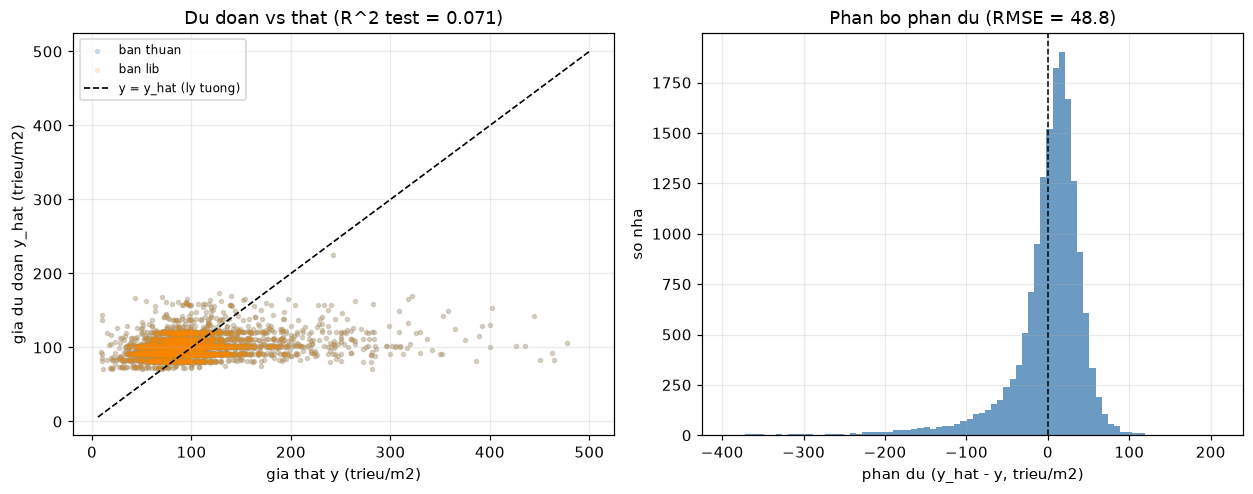


Nhan xet:
- Tap hop diem nam xen ke duong y=y_hat nhung rong (phang): R^2 thap (0.071).
- Phan du tap trung quanh 0 nhung lech lon (RMSE ~ 49 trieu/m2).
  -> Chi area + phong ngu KHONG du bao gia/m2; vi tri (Quan) moi la yeu to quyet dinh (nhu EDA b1).


In [8]:
# === Do thi: du doan vs gia that (tap test) + bieu do phan bo ===
yp_p = Xte_s @ w_p + b_p
yp_l = clf.predict(Xte_s)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.6))

# (a) Scatter du doan vs that - lay mau con de de nhin
idx = np.random.default_rng(0).choice(len(yte), size=min(4000, len(yte)), replace=False)
a1.scatter(yte[idx], yp_p[idx], s=7, alpha=0.22, color="steelblue", label="ban thuan")
a1.scatter(yte[idx], yp_l[idx], s=7, alpha=0.14, color="darkorange", label="ban lib")
m = np.array([yte.min(), yte.max()])
a1.plot(m, m, "k--", lw=1.1, label="y = y_hat (ly tuong)")
a1.set_xlabel("gia that y (trieu/m2)"); a1.set_ylabel("gia du doan y_hat (trieu/m2)")
a1.set_title("Du doan vs that (R^2 test = %.3f)" % r2_te_p)
a1.legend(fontsize=8, loc="upper left"); a1.grid(alpha=0.25)

# (b) Histogram phan du - nhin ro ML chenh lech
res = yp_p - yte
a2.hist(res, bins=80, color="steelblue", alpha=0.8)
a2.axvline(0, color="k", ls="--", lw=1)
a2.set_xlabel("phan du (y_hat - y, trieu/m2)"); a2.set_ylabel("so nha")
a2.set_title("Phan bo phan du (RMSE = %.1f)" % rmse_te_p); a2.grid(alpha=0.25)
fig.tight_layout(); plt.show()

print("\nNhan xet:")
print("- Tap hop diem nam xen ke duong y=y_hat nhung rong (phang): R^2 thap (%.3f)." % r2_te_p)
print("- Phan du tap trung quanh 0 nhung lech lon (RMSE ~ %.0f trieu/m2)." % rmse_te_p)
print("  -> Chi area + phong ngu KHONG du bao gia/m2; vi tri (Quan) moi la yeu to quyet dinh (nhu EDA b1).")

## 5. Thảo luận — vì sao $R^2$ thấp nhưng bản thuần vẫn "đúng"?

**1. Bản thuần ≡ thư viện về mặt toán.** Sai khác trọng số chỉ ở bậc $10^{-13}$ (làm tròn float). Điều này chứng tỏ gradient descent nguyên bản đã **hội tụ tới cực tiểu toàn cục** của MSE. Khác với softmax (hàm mất mát phi lồi, GD dừng giữa chừng nên kém hơn solver bậc hai), với hồi quy tuyến tính **không có khoảng cách chất lượng** giữa GD và OLS — đây chính là điểm sư phạm của notebook.

**2. Vậy tại sao $R^2 pprox 0.07$ rất thấp?** Vì giá/m² nhà đất Hà Nội phụ thuộc chủ yếu vào **địa điểm** (Quận nào, trung tâm hay ngoại ô), **loại đường** (mặt tiền hay ngõ), **pháp lý**, ... — không phải diện tích hay số phòng ngủ. Hai đặc trưng area + bed gần như **không mang thông tin** về yếu tố quyết định giá. Đây đúng là kết luận của báo cáo EDA (b1): `Quận` là biến tương quan mạnh nhất với giá, nhưng notebook này cố ý chỉ dùng area + bed để minh hoạ **phương pháp** (giải tay → thuần → lib), chưa phải để dự đoán chính xác.

**3. RMSE = 48.8 triệu/m² nghĩa gì?** Sai số trung bình bình phương ~ 48.8 triệu/m² — rất lớn so với giá trung bình ~100 triệu/m² (sai số gần 50%). Mô hình cơ bản chỉ đoán gần **giá trung bình** cho mọi nhà; nó không phân biệt được nhà đắt/quen.

**4. Hệ số học được có ý nghĩa gì?** `w_area ≈ 3.28`, `w_bed ≈ 13.18` trên đặc trưng chuẩn hoá: phòng ngủ "đóng góp" hơn diện tích vào giá/m², nhưng cả hai đều nhỏ so với độ lệch tự nhiên của giá. Thiên lệch `b ≈ 100.4` chính là gần giá trung bình — dấu hiệu của mô hình "gần như chỉ trả trung bình".

**5. Đâu là bước cải tiến tiếp theo?** Thêm đặc trưng **Quận** (one-hot) và **loại đường** — như EDA b1 đã chỉ ra. Đó là hướng mở rộng tự nhiên, nhưng nằm ngoài phạm vi minh hoạ phương pháp của notebook này.

## 6. Kết luận — cái nào "tốt hơn"?

- **Hiểu thuật toán:** bản thuần là tốt nhất — mỗi dòng mã ánh xạ một công thức gradient; có thể kiểm chứng bằng sai phân hữu hạn và gỡ rối tận gốc.
- **Dùng thực tế:** thư viện tốt hơn — giải OLS chính xác trong phần trăm giây, không cần kẹm learning rate hay số epoch.
- **Với hồi quy tuyến tính:** hai cách cho **cùng đáp số** vì MSE lồi — điểm khác biệt căn bản so với softmax (phi lồi). Đó là bài học cốt lõi: **tính chất toán của hàm mất mát quyết định liệu GD có đủ hay không.**
- **$R^2$ thấp không phải lỗi cài đặt** mà là dữ liệu: area + bed không đủ để đoán giá/m², cần thêm địa điểm (Quận) — đúng kết luận EDA b1.

> Ba giai đoạn (giải tay → bản thuần → thư viện), cùng một đáp số trên dữ liệu nhà đất Hà Nội — đó là cách kiểm chứng bản tự cài đã đúng, đồng thời thấy rõ giới hạn của mô hình tuyến tính khi thiếu đặc trưng quan trọng.